In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:

df = pd.read_csv("data/Mall_Customers.csv")


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [7]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

print("Selected Features:", features)
print("Feature Shape:", X.shape)

Selected Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Feature Shape: (200, 2)


In [9]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [11]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [15]:
X_scaled_df.describe()

,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02
mean,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00
min,-1.738999e+00,-1.910021e+00
25%,-7.275093e-01,-5.997931e-01
50%,3.587926e-02,-7.764312e-03
75%,6.656748e-01,8.851316e-01
max,2.917671e+00,1.894492e+00


In [17]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print("Original Shape:", X_scaled.shape)
print("PCA Shape:", X_pca.shape)

Original Shape: (200, 2)
PCA Shape: (200, 2)


In [19]:
print("Principal Components:")
print(pca.components_)

Principal Components:
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [21]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)

pca_components

,Annual Income (k$),Spending Score (1-100)
PC1,0.707107,0.707107
PC2,0.707107,-0.707107


In [23]:
explained_variance = pca.explained_variance_ratio_

print(
    "Explained Variance Ratio:",
    explained_variance
)

print(
    "Total Explained Variance:",
    explained_variance.sum()
)

Explained Variance Ratio: [0.50495142 0.49504858]
Total Explained Variance: 1.0


In [25]:
explained_variance_df = pd.DataFrame({
    "Component": [
        "PC1",
        "PC2"
    ],
    "Explained_Variance": explained_variance,
    "Explained_Variance_Percentage": (
        explained_variance * 100
    ).round(2)
})

explained_variance_df

,Component,Explained_Variance,Explained_Variance_Percentage
0,PC1,0.504951,50.5
1,PC2,0.495049,49.5


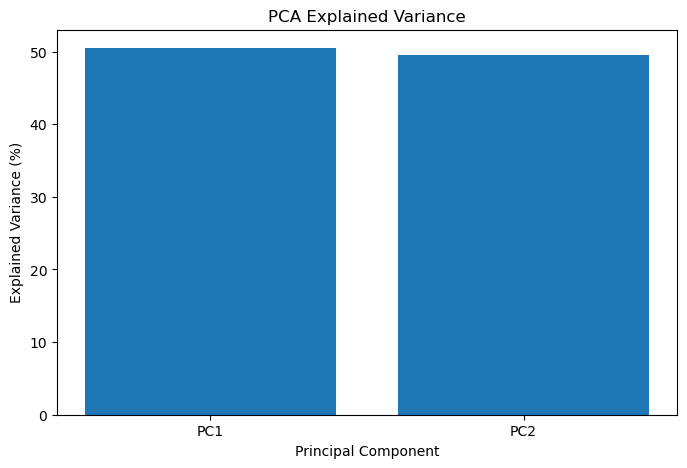

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance * 100
)

plt.title("PCA Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.show()

In [29]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df.head()

,PC1,PC2
0,-1.537109,-0.922207
1,-0.384168,-2.075149
2,-2.416002,0.010665
3,-0.466982,-1.938355
4,-1.455678,-0.895678


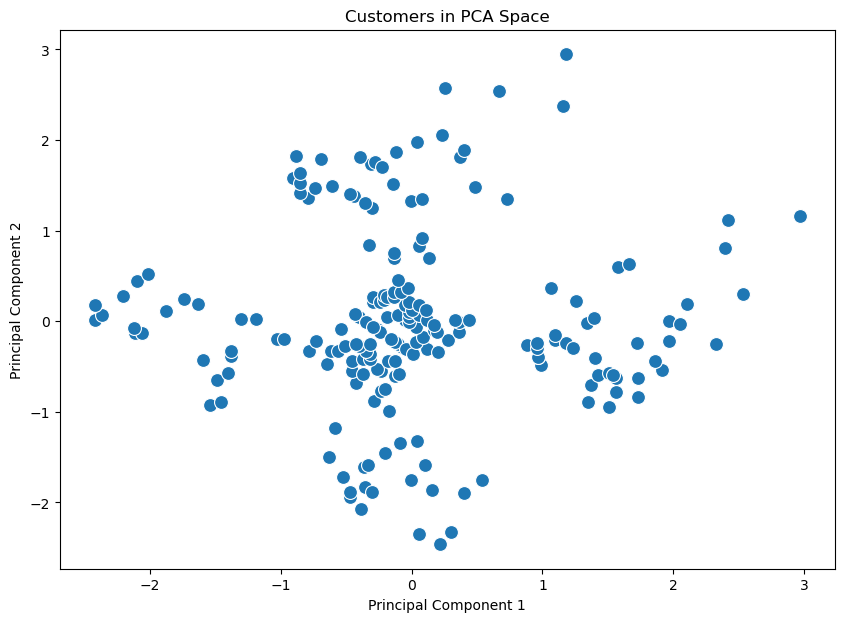

In [31]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    s=100
)

plt.title(
    "Customers in PCA Space"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()

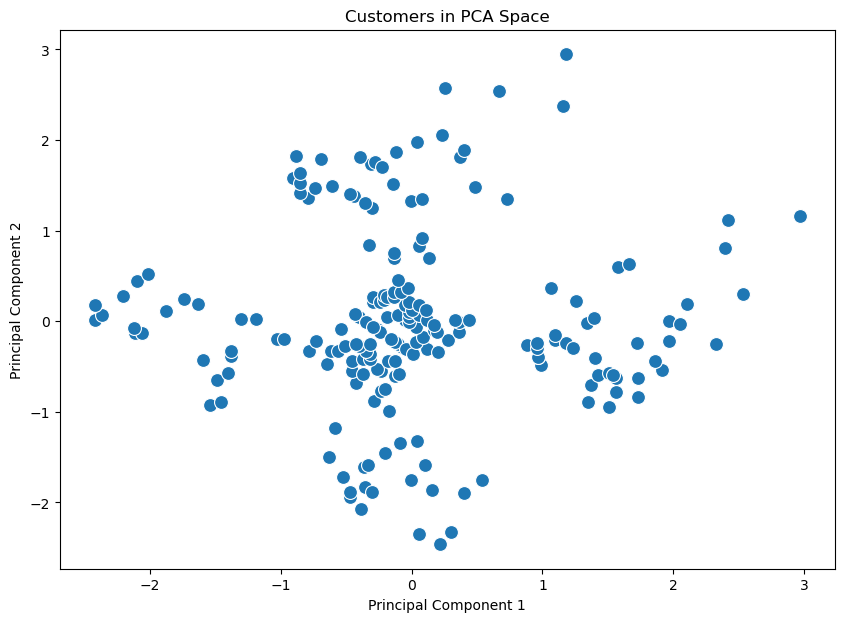

In [33]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    s=100
)

plt.title(
    "Customers in PCA Space"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()

In [35]:
pca_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

pca_labels = pca_kmeans.fit_predict(
    X_pca
)

In [37]:
pca_silhouette = silhouette_score(
    X_pca,
    pca_labels
)

print(
    "PCA + K-Means Silhouette Score:",
    round(
        pca_silhouette,
        4
    )
)

PCA + K-Means Silhouette Score: 0.5547


In [39]:
pca_df["Cluster"] = pca_labels

pca_df.head()

,PC1,PC2,Cluster
0,-1.537109,-0.922207,4
1,-0.384168,-2.075149,2
2,-2.416002,0.010665,4
3,-0.466982,-1.938355,2
4,-1.455678,-0.895678,4


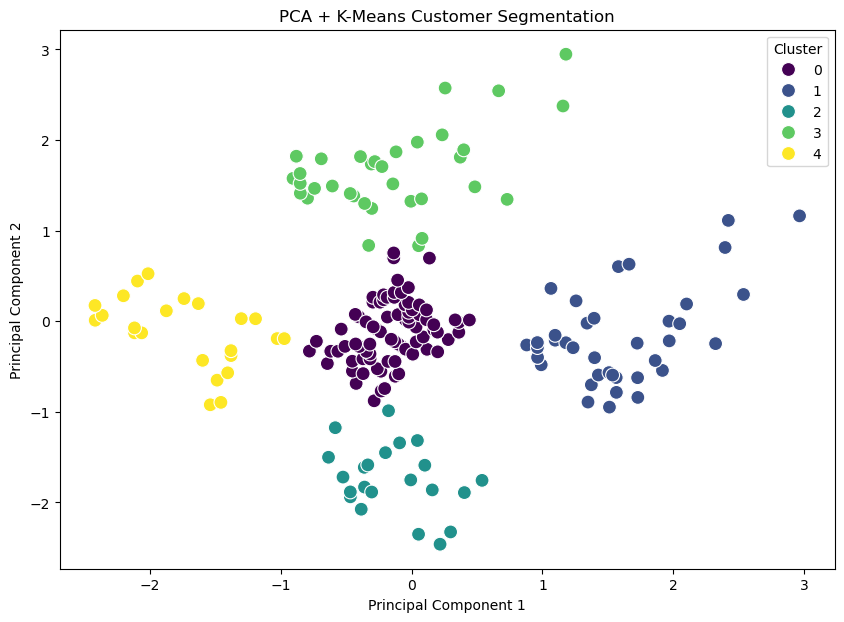

In [41]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title(
    "PCA + K-Means Customer Segmentation"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.legend(
    title="Cluster"
)

plt.show()

In [43]:
df_pca = df.copy()

df_pca["PCA_Cluster"] = pca_labels

df_pca.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),PCA_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [45]:
pca_profile = df_pca.groupby(
    "PCA_Cluster"
).agg(
    Customer_Count=(
        "CustomerID",
        "count"
    ),
    Average_Age=(
        "Age",
        "mean"
    ),
    Average_Income=(
        "Annual Income (k$)",
        "mean"
    ),
    Average_Spending=(
        "Spending Score (1-100)",
        "mean"
    )
).round(2)

pca_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
PCA_Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [47]:
pca_profile.sort_values(
    "Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
PCA_Cluster,,,,
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
0,81,42.72,55.30,49.52
4,23,45.22,26.30,20.91
3,35,41.11,88.20,17.11


In [49]:
pca_1d = PCA(
    n_components=1
)

X_pca_1d = pca_1d.fit_transform(
    X_scaled
)

print(
    "Original Shape:",
    X_scaled.shape
)

print(
    "Reduced Shape:",
    X_pca_1d.shape
)

Original Shape: (200, 2)
Reduced Shape: (200, 1)


In [51]:
variance_1d = (
    pca_1d
    .explained_variance_ratio_
    .sum()
)

print(
    "Variance Retained:",
    round(
        variance_1d * 100,
        2
    ),
    "%"
)

Variance Retained: 50.5 %


In [53]:
pca_1d_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

pca_1d_labels = pca_1d_kmeans.fit_predict(
    X_pca_1d
)

In [55]:
pca_1d_silhouette = silhouette_score(
    X_pca_1d,
    pca_1d_labels
)

print(
    "1D PCA + K-Means Silhouette:",
    round(
        pca_1d_silhouette,
        4
    )
)

1D PCA + K-Means Silhouette: 0.545


In [57]:
pca_comparison = pd.DataFrame({
    "Method": [
        "Original K-Means",
        "PCA + K-Means (2 Components)",
        "PCA + K-Means (1 Component)"
    ],
    
    "Silhouette_Score": [
        0.5547,
        pca_silhouette,
        pca_1d_silhouette
    ]
})

pca_comparison

,Method,Silhouette_Score
0,Original K-Means,0.554700
1,PCA + K-Means (2 Components),0.554657
2,PCA + K-Means (1 Component),0.544970


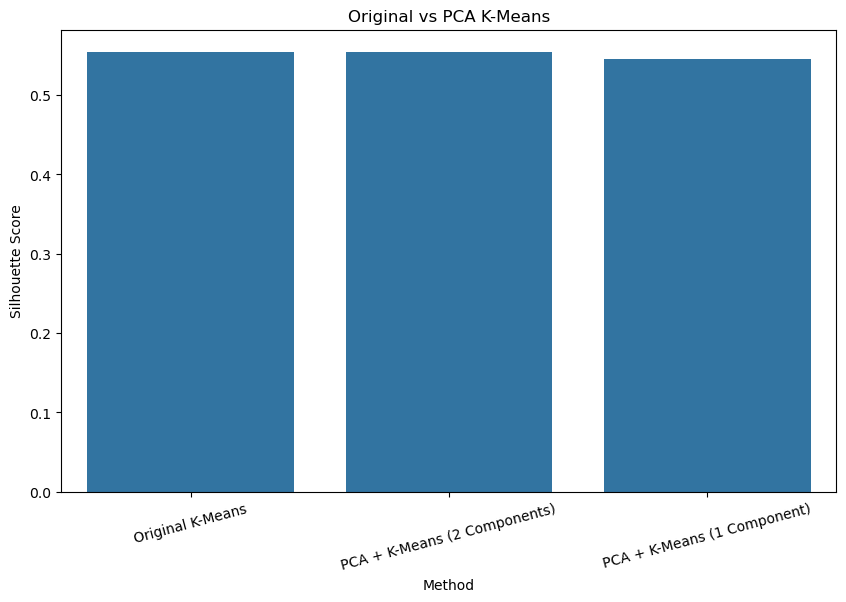

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=pca_comparison,
    x="Method",
    y="Silhouette_Score"
)

plt.title(
    "Original vs PCA K-Means"
)

plt.xlabel("Method")
plt.ylabel("Silhouette Score")

plt.xticks(
    rotation=15
)

plt.show()

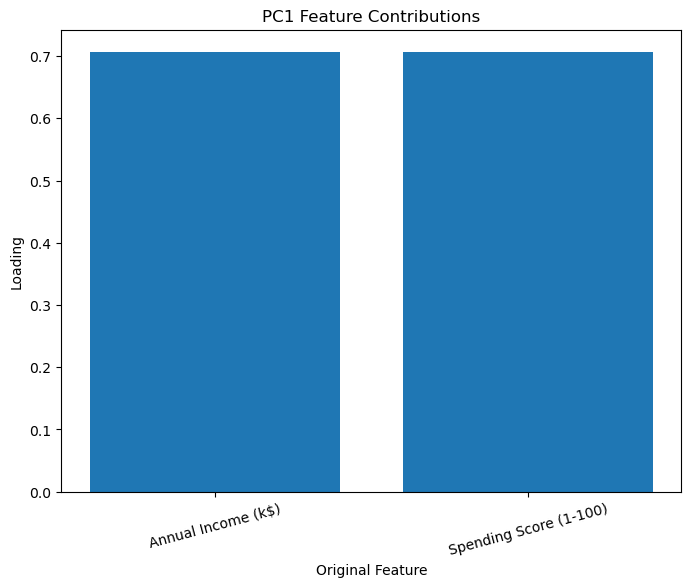

In [61]:
plt.figure(figsize=(8, 6))

plt.bar(
    features,
    pca.components_[0]
)

plt.title(
    "PC1 Feature Contributions"
)

plt.xlabel("Original Feature")
plt.ylabel("Loading")

plt.xticks(
    rotation=15
)

plt.show()

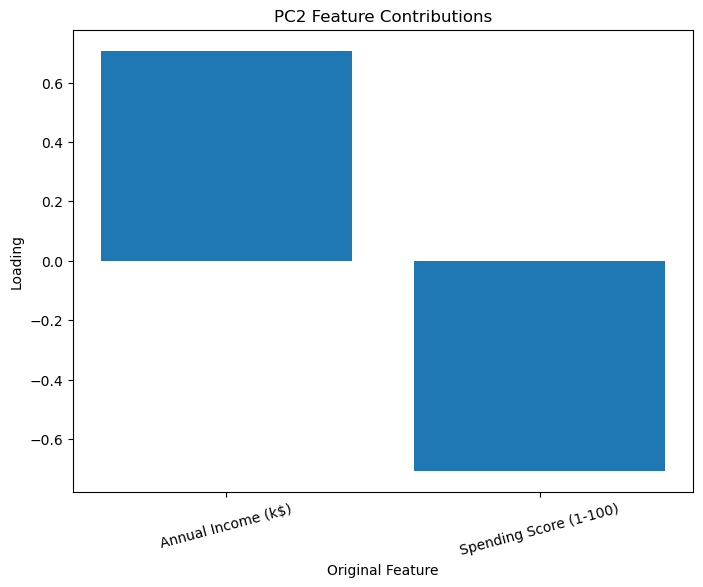

In [63]:
plt.figure(figsize=(8, 6))

plt.bar(
    features,
    pca.components_[1]
)

plt.title(
    "PC2 Feature Contributions"
)

plt.xlabel("Original Feature")
plt.ylabel("Loading")

plt.xticks(
    rotation=15
)

plt.show()

In [65]:
df_pca.to_csv(
    "outputs/results/pca_customer_segments.csv",
    index=False
)

print(
    "PCA customer segments saved."
)

PCA customer segments saved.


In [67]:
pca_profile.to_csv(
    "outputs/results/pca_cluster_summary.csv"
)

print(
    "PCA cluster summary saved."
)

PCA cluster summary saved.


In [69]:
pca_comparison.to_csv(
    "outputs/results/pca_clustering_comparison.csv",
    index=False
)

print(
    "PCA comparison saved."
)

PCA comparison saved.


In [71]:
import joblib

joblib.dump(
    pca,
    "models/pca_model.pkl"
)

joblib.dump(
    scaler,
    "models/pca_scaler.pkl"
)

print(
    "PCA model and scaler saved."
)

PCA model and scaler saved.


In [73]:
print("=" * 50)
print("PCA CUSTOMER SEGMENTATION REPORT")
print("=" * 50)

print(
    "\nOriginal Features:",
    len(features)
)

print(
    "PCA Components:",
    X_pca.shape[1]
)

print(
    "\nExplained Variance:"
)

for component, variance in zip(
    ["PC1", "PC2"],
    explained_variance
):
    print(
        f"{component}: {variance * 100:.2f}%"
    )

print(
    "\nTotal Variance:",
    f"{explained_variance.sum() * 100:.2f}%"
)

print(
    "\nPCA + K-Means Silhouette:",
    round(pca_silhouette, 4)
)

print(
    "1D PCA + K-Means Silhouette:",
    round(pca_1d_silhouette, 4)
)

print("=" * 50)

PCA CUSTOMER SEGMENTATION REPORT

Original Features: 2
PCA Components: 2

Explained Variance:
PC1: 50.50%
PC2: 49.50%

Total Variance: 100.00%

PCA + K-Means Silhouette: 0.5547
1D PCA + K-Means Silhouette: 0.545
